# StreamView Analytics
## Solución integral de visualización para adquisición y priorización de contenidos

Este notebook reúne en un único flujo reproducible el análisis de negocio, la preparación de datos, el análisis exploratorio y el prototipo interactivo de StreamView Analytics.

La solución está orientada principalmente a la Gerencia de Contenidos y Adquisición. Su propósito es transformar el catálogo audiovisual en evidencia visual para apoyar decisiones de adquisición, promoción, posicionamiento y gestión de contenidos.

### Recorrido del análisis

1. Definir el problema, la audiencia y las preguntas de negocio.
2. Cargar, integrar y preparar las fuentes de películas y series.
3. Explorar la composición, concentración, evolución y desempeño del catálogo.
4. Construir un panel interactivo para comparar segmentos y priorizar revisiones.
5. Validar la calidad de las relaciones y de los resultados generados.

> **Criterios de interpretación:** `popularity` es un índice relativo y no representa reproducciones. Las calificaciones iguales a cero no se consideran válidas. El análisis financiero se limita a películas con presupuesto e ingresos positivos.

## 1. Contexto y preguntas de negocio

StreamView Analytics dispone de un catálogo de películas y series con información de títulos, directores, reparto, países, idiomas, géneros, fechas, popularidad, votos, calificaciones y variables financieras para películas.

El problema de negocio es que la información se encuentra distribuida y resulta difícil obtener una visión consolidada, comparar mercados y géneros o seleccionar contenidos para campañas. Por ello, el análisis busca responder:

- ¿Cómo se distribuye el catálogo entre películas y series?
- ¿Qué géneros, países e idiomas concentran la oferta?
- ¿Cómo evoluciona el catálogo según el año de estreno?
- ¿Qué contenidos destacan por popularidad y valoración?
- ¿Qué categorías y títulos conviene priorizar para revisión?
- ¿Qué películas presentan un retorno observado mayor sobre el presupuesto?

Los indicadores principales serán el volumen de contenidos, la distribución por tipo, género, país e idioma, la popularidad mediana, la valoración válida, la cantidad de votos y el retorno observado de películas con información financiera disponible.

In [1]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from IPython.display import HTML, display

# El notebook puede ejecutarse desde la raíz del proyecto o desde notebooks/.
possible_roots = [Path.cwd(), Path.cwd().parent]
project_root = next((root for root in possible_roots if (root / "data").exists()), Path.cwd())
data_dir = project_root / "data"

movies_path = data_dir / "netflix_movies_detailed_up_to_2025.csv"
shows_path = data_dir / "netflix_tv_shows_detailed_up_to_2025.csv"
clean_path = data_dir / "streamview_catalogo_limpio.csv"

movies = pd.read_csv(movies_path)
shows = pd.read_csv(shows_path)

print(f"Películas: {movies.shape[0]:,} registros y {movies.shape[1]} columnas")
print(f"Series: {shows.shape[0]:,} registros y {shows.shape[1]} columnas")

Películas: 16,000 registros y 18 columnas
Series: 16,000 registros y 16 columnas


## 2. Integración y preparación de datos

Se mantiene una fila por contenido audiovisual y se unifican las columnas comunes de películas y series. Las variables `budget` e `revenue` se agregan a las series como valores faltantes porque no son comparables entre ambos tipos.

El proceso incluye normalización de nombres y textos, conversión de fechas y variables numéricas, tratamiento de valores financieros no válidos, eliminación de duplicados por `show_id` y creación de métricas derivadas.

In [2]:
text_columns = [
    "type", "title", "director", "cast", "country", "rating",
    "duration", "genres", "language", "description",
]

movies_clean = movies.copy()
shows_clean = shows.copy()
for column in ["budget", "revenue"]:
    shows_clean[column] = pd.NA

catalog = pd.concat([movies_clean, shows_clean], ignore_index=True, sort=False)
catalog.columns = catalog.columns.str.strip().str.lower()

for column in text_columns:
    catalog[column] = catalog[column].astype("string").str.strip()
    if column != "description":
        catalog[column] = catalog[column].fillna("Sin información")

catalog["title"] = catalog["title"].fillna("Sin título")
catalog["show_id"] = pd.to_numeric(catalog["show_id"], errors="coerce").astype("Int64")
catalog["date_added"] = pd.to_datetime(catalog["date_added"], errors="coerce")

numeric_columns = ["release_year", "popularity", "vote_count", "vote_average", "budget", "revenue"]
for column in numeric_columns:
    catalog[column] = pd.to_numeric(catalog[column], errors="coerce")

# Cero o valores negativos representan información financiera no disponible.
for column in ["budget", "revenue"]:
    catalog.loc[catalog[column] <= 0, column] = pd.NA

catalog = catalog.drop_duplicates(subset="show_id", keep="first").reset_index(drop=True)
catalog["date_added_year"] = catalog["date_added"].dt.year.astype("Int64")
catalog["roi"] = catalog["revenue"] / catalog["budget"]

catalog_export = catalog.copy()
catalog_export["date_added"] = catalog_export["date_added"].dt.strftime("%Y-%m-%d")
catalog_export.to_csv(clean_path, index=False)

print(f"Catálogo integrado: {catalog.shape[0]:,} registros y {catalog.shape[1]} columnas")
print(f"Duplicados restantes por show_id: {catalog['show_id'].duplicated().sum()}")
print(f"Archivo limpio: {clean_path}")

Catálogo integrado: 31,594 registros y 20 columnas
Duplicados restantes por show_id: 0
Archivo limpio: /home/liquuid/DUOC/Visualización de datos/EV1-VizualicacionDatos/data/streamview_catalogo_limpio.csv


In [3]:
def explode_dimension(dataframe, column, output_column):
    """Creates one row per content-category association."""
    dimension = dataframe[["show_id", "type", "title", column]].copy()
    dimension[output_column] = dimension[column].fillna("Sin información").astype(str).str.split(",")
    dimension = dimension.explode(output_column)
    dimension[output_column] = dimension[output_column].str.strip()
    return dimension[~dimension[output_column].isin(["", "Sin información"])]


genres = explode_dimension(catalog, "genres", "genre")
countries = explode_dimension(catalog, "country", "country_name")

quality_report = pd.DataFrame({
    "column": catalog.columns,
    "dtype": catalog.dtypes.astype(str).values,
    "missing": catalog.isna().sum().values,
    "missing_pct": catalog.isna().mean().mul(100).round(2).values,
}).sort_values("missing", ascending=False)

print(f"Asociaciones de género: {len(genres):,}")
print(f"Asociaciones de país: {len(countries):,}")
quality_report.head(8)

Asociaciones de género: 65,180
Asociaciones de país: 37,227


,column,dtype,missing,missing_pct
19,roi,float64,28054,88.80
16,budget,float64,26747,84.66
17,revenue,float64,25949,82.13
12,description,string,3268,10.34
3,director,string,0,0.00
2,title,string,0,0.00
1,type,string,0,0.00
0,show_id,Int64,0,0.00


## 3. Análisis exploratorio

El EDA busca describir la composición del catálogo, reconocer concentraciones por categoría y país, observar la evolución temporal y comparar las señales de popularidad, valoración e información financiera.

In [4]:
content_by_type = (
    catalog["type"]
    .value_counts()
    .rename_axis("type")
    .reset_index(name="contents")
)

genre_counts = (
    genres.groupby("genre", as_index=False)
    .agg(contents=("show_id", "nunique"))
    .sort_values("contents", ascending=False)
)

country_counts = (
    countries.groupby("country_name", as_index=False)
    .agg(contents=("show_id", "nunique"))
    .sort_values("contents", ascending=False)
)

yearly = (
    catalog.groupby("release_year", as_index=False)
    .agg(contents=("show_id", "nunique"))
    .sort_values("release_year")
)

language_counts = (
    catalog.loc[~catalog["language"].isin(["Sin información", "", "nan"]), "language"]
    .value_counts()
    .rename_axis("language")
    .reset_index(name="contents")
)

display(content_by_type)
display(genres.head(3))
display(country_counts.head(10))

,type,contents
0,Movie,16000
1,TV Show,15594


,show_id,type,title,genres,genre
0,10192,Movie,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Comedy
0,10192,Movie,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Adventure
0,10192,Movie,Shrek Forever After,"Comedy, Adventure, Fantasy, Animation, Family",Fantasy


,country_name,contents
140,United States of America,10874
63,Japan,2822
138,United Kingdom,2583
27,China,2369
120,South Korea,2139
44,France,2099
23,Canada,1697
47,Germany,1155
56,India,902
121,Spain,809


### 3.1 Composición y evolución

Las barras permiten comparar cantidades entre tipos y categorías; la línea permite observar la concentración temporal de los estrenos. En los gráficos siguientes se muestran las dimensiones más relevantes del catálogo.

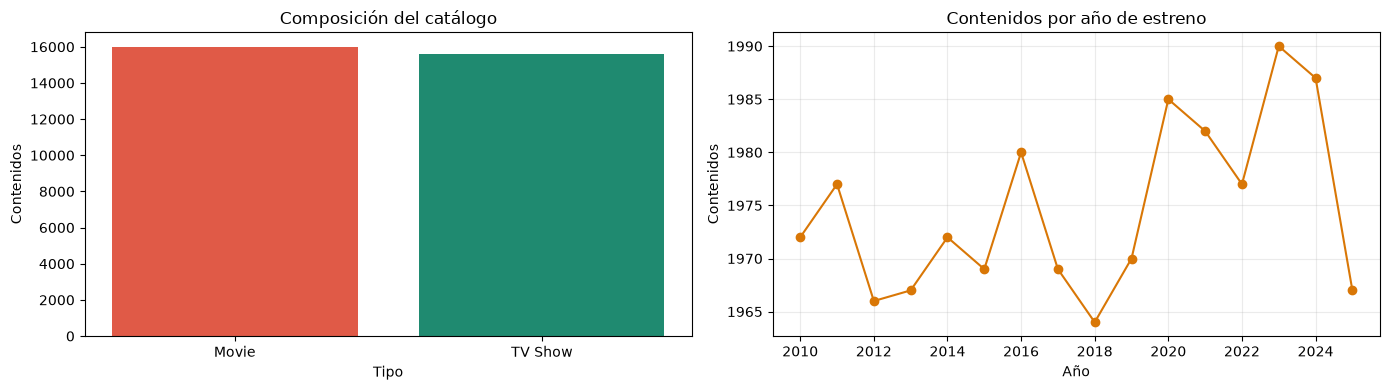

Géneros con mayor presencia:


,contents
genre,
Drama,14571
Comedy,8983
Animation,4000
Thriller,3769
Action,3239
Crime,3168
Family,2967
Romance,2571
Mystery,2555


Países con mayor presencia:


,country_name,contents
140,United States of America,10874
63,Japan,2822
138,United Kingdom,2583
27,China,2369
120,South Korea,2139
44,France,2099
23,Canada,1697
47,Germany,1155
56,India,902
121,Spain,809


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(content_by_type["type"], content_by_type["contents"], color=["#e05a47", "#1f8a70"])
axes[0].set_title("Composición del catálogo")
axes[0].set_xlabel("Tipo")
axes[0].set_ylabel("Contenidos")

axes[1].plot(yearly["release_year"], yearly["contents"], marker="o", color="#d97706")
axes[1].set_title("Contenidos por año de estreno")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Contenidos")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Géneros con mayor presencia:")
display(genres.groupby("genre")["show_id"].nunique().sort_values(ascending=False).head(10).rename("contents").to_frame())
print("Países con mayor presencia:")
display(country_counts.head(10))

### 3.2 Popularidad, valoración y oportunidades

La popularidad se interpreta como visibilidad relativa. Para comparar categorías se utiliza la mediana y se exige un mínimo de 25 contenidos. Para priorizar títulos calificados se exige además un mínimo de 100 votos, reduciendo el riesgo de interpretar casos aislados.

In [6]:
catalog["has_rating"] = catalog["vote_average"].gt(0)

popular_titles = catalog.nlargest(10, "popularity")[[
    "title", "type", "release_year", "popularity", "vote_average", "vote_count"
]]

best_rated_titles = (
    catalog[catalog["has_rating"] & catalog["vote_count"].ge(100)]
    .nlargest(10, "vote_average")[[
        "title", "type", "release_year", "vote_average", "vote_count", "popularity"
    ]]
)

category_opportunities = (
    genres.merge(catalog[["show_id", "popularity"]], on="show_id")
    .groupby("genre", as_index=False)
    .agg(contents=("show_id", "nunique"), median_popularity=("popularity", "median"))
    .query("contents >= 25")
    .nlargest(10, "median_popularity")
)

print("Contenidos más populares")
display(popular_titles)
print("Contenidos mejor calificados con al menos 100 votos")
display(best_rated_titles)
print("Categorías con mayor popularidad típica")
display(category_opportunities)

Contenidos más populares


,title,type,release_year,popularity,vote_average,vote_count
20854,The Late Show with Stephen Colbert,TV Show,2015,6421.923,6.493,288
19882,The Tonight Show Starring Jimmy Fallon,TV Show,2014,4925.253,5.800,321
15000,The Gorge,Movie,2025,3876.006,7.785,1572
17949,Good Mythical Morning,TV Show,2012,3414.466,6.800,67
15001,Flight Risk,Movie,2025,3320.616,6.000,350
23772,Chronicles of the Sun,TV Show,2018,2987.485,6.800,117
29640,Volta por Cima,TV Show,2024,2885.720,5.781,16
29641,She's the One,TV Show,2024,2862.872,8.100,9
14000,Mufasa: The Lion King,Movie,2024,2643.627,7.467,1497
29644,Crazy About You,TV Show,2024,2442.243,5.200,16


Contenidos mejor calificados con al menos 100 votos


,title,type,release_year,vote_average,vote_count,popularity
7103,Nude,Movie,2017,9.500,161,27.026
14763,Succubus,Movie,2024,9.500,157,15.457
13392,Kill Shot,Movie,2023,9.300,158,19.092
10878,Break the Silence: The Movie,Movie,2020,9.000,183,6.845
10601,The Three Deaths of Marisela Escobedo,Movie,2020,8.900,228,9.243
12784,BTS: Permission to Dance on Stage - LA,Movie,2022,8.900,157,9.365
28846,The Good Bad Mother,TV Show,2023,8.900,149,64.362
28893,Adventure Time: Fionna & Cake,TV Show,2023,8.900,208,53.227
29458,The Boy's Word: Blood on the Asphalt,TV Show,2023,8.887,182,27.448
26708,Arcane,TV Show,2021,8.800,4932,191.815


Categorías con mayor popularidad típica


,genre,contents,median_popularity
20,Soap,615,88.1160
15,News,109,53.5560
22,Talk,643,51.0720
16,Reality,1589,41.0335
12,Kids,812,40.9880
1,Action & Adventure,1935,38.8130
18,Sci-Fi & Fantasy,1909,37.8630
26,War & Politics,314,34.3460
24,Unknown,96,31.3530
3,Animation,4000,26.8320


### 3.3 Desempeño financiero

El análisis financiero se limita a películas con presupuesto e ingresos positivos. El retorno observado se calcula como `revenue / budget`; no representa rentabilidad completa porque no incorpora costos de marketing, distribución, licencias ni operación.

In [7]:
financial = catalog[catalog["type"].eq("Movie") & catalog["budget"].gt(0) & catalog["revenue"].gt(0)].copy()
financial_top = financial.nlargest(10, "roi")

if financial.empty:
    print("No existen películas con información financiera válida para este segmento.")
else:
    financial_figure = px.bar(
        financial_top.sort_values("roi"),
        x="roi",
        y="title",
        orientation="h",
        color="roi",
        log_x=True,
        labels={"roi": "ROI aproximado", "title": "Película"},
        title="Películas con mayor retorno observado",
    )
    financial_figure.show()
    display(financial_top[["title", "budget", "revenue", "roi"]])

,title,budget,revenue,roi
6269,The Beatles: Eight Days a Week - The Touring Y...,5.0,12283800.0,2.456760e+06
13648,No Dogs or Italians Allowed,5.0,1395922.0,2.791844e+05
13935,Scrapper,84.0,1234483.0,1.469623e+04
12594,The Good Neighbor,105.0,94909.0,9.038952e+02
8803,Animal World,125000.0,69885700.0,5.590856e+02
5339,Mr. Six,250000.0,139191345.0,5.567654e+02
7238,One Cut of the Dead,52406.0,27590180.0,5.264699e+02
7739,Secret Superstar,286284.0,137416709.0,4.800014e+02
5365,The Gallows,100000.0,42964410.0,4.296441e+02
9258,Freaks,2000.0,368410.0,1.842050e+02


## 4. Panel interactivo de exploración

El panel responde a una pregunta de adquisición: **¿qué parte del catálogo quiero comparar y bajo qué criterio de desempeño?** Los filtros actualizan KPIs, composición, oportunidades, rankings y finanzas.

In [8]:
def options_with_all(values):
    values = sorted(value for value in values if pd.notna(value) and str(value) != "Sin información")
    return ["Todos"] + values


genre_options = options_with_all(genres["genre"].unique())
country_options = options_with_all(countries["country_name"].unique())
year_values = sorted(catalog["release_year"].dropna().astype(int).unique())

content_type = widgets.Dropdown(options=["Todos", "Movie", "TV Show"], value="Todos", description="Tipo:")
genre_filter = widgets.Dropdown(options=genre_options, value="Todos", description="Género:")
country_filter = widgets.Dropdown(options=country_options, value="Todos", description="País:")
year_filter = widgets.SelectionRangeSlider(
    options=year_values,
    index=(0, len(year_values) - 1),
    description="Estreno:",
    continuous_update=False,
    layout=widgets.Layout(width="520px"),
)
ranking_metric = widgets.Dropdown(
    options=[("Popularidad", "popularity"), ("Valoración", "vote_average"), ("Votos", "vote_count")],
    value="popularity",
    description="Ranking:",
)
top_n = widgets.IntSlider(value=10, min=5, max=20, step=5, description="Top:")

In [9]:
def filter_catalog(selected_type, selected_genre, selected_country, selected_years):
    start_year, end_year = selected_years
    filtered = catalog[catalog["release_year"].between(start_year, end_year)].copy()

    if selected_type != "Todos":
        filtered = filtered[filtered["type"].eq(selected_type)]
    if selected_genre != "Todos":
        valid_ids = set(genres.loc[genres["genre"].eq(selected_genre), "show_id"])
        filtered = filtered[filtered["show_id"].isin(valid_ids)]
    if selected_country != "Todos":
        valid_ids = set(countries.loc[countries["country_name"].eq(selected_country), "show_id"])
        filtered = filtered[filtered["show_id"].isin(valid_ids)]
    return filtered


def render_dashboard(selected_type, selected_genre, selected_country, selected_years, selected_metric, selected_top_n):
    filtered = filter_catalog(selected_type, selected_genre, selected_country, selected_years)
    if filtered.empty:
        display(HTML("<b>No hay contenidos para esta combinación de filtros.</b>"))
        return

    display(HTML("<h3>Lectura ejecutiva</h3>"))
    display(pd.DataFrame({
        "Indicador": ["Contenidos", "Películas", "Series", "Popularidad mediana", "Valoración válida"],
        "Valor": [
            f"{len(filtered):,}",
            f"{filtered['type'].eq('Movie').sum():,}",
            f"{filtered['type'].eq('TV Show').sum():,}",
            f"{filtered['popularity'].median():,.1f}",
            f"{filtered.loc[filtered['has_rating'], 'vote_average'].mean():,.2f} / 10" if filtered["has_rating"].any() else "Sin datos",
        ],
    }))

    type_counts = filtered["type"].value_counts().rename_axis("type").reset_index(name="contents")
    yearly_filtered = filtered.groupby("release_year", as_index=False).agg(contents=("show_id", "nunique"))
    display(px.bar(type_counts, x="type", y="contents", color="type", title="Composición del segmento"))
    display(px.line(yearly_filtered, x="release_year", y="contents", markers=True, title="Evolución de los estrenos"))

    filtered_genres = genres[genres["show_id"].isin(filtered["show_id"])]
    opportunity = (
        filtered_genres.merge(filtered[["show_id", "popularity"]], on="show_id")
        .groupby("genre", as_index=False)
        .agg(contents=("show_id", "nunique"), median_popularity=("popularity", "median"))
        .query("contents >= 25")
        .nlargest(10, "median_popularity")
    )
    display(px.bar(opportunity.sort_values("median_popularity"), x="median_popularity", y="genre", orientation="h", color="contents", title="Géneros con mayor popularidad típica"))

    ranking = filtered.nlargest(selected_top_n, selected_metric)[["title", "type", "release_year", "popularity", "vote_average", "vote_count"]]
    display(HTML("<h3>Títulos prioritarios para revisión</h3>"))
    display(ranking)

controls = widgets.VBox([content_type, genre_filter, country_filter, year_filter, ranking_metric, top_n])
dashboard_output = widgets.interactive_output(
    render_dashboard,
    {
        "selected_type": content_type,
        "selected_genre": genre_filter,
        "selected_country": country_filter,
        "selected_years": year_filter,
        "selected_metric": ranking_metric,
        "selected_top_n": top_n,
    },
)
display(controls, dashboard_output)

Output()

## 5. Validaciones y lectura final

Las comprobaciones finales verifican que el catálogo integrado no tenga identificadores duplicados, que las dimensiones auxiliares solo referencien contenidos existentes y que las métricas financieras se calculen exclusivamente para películas con datos positivos.

In [10]:
assert catalog["show_id"].notna().all()
assert catalog["show_id"].is_unique
assert genres["show_id"].isin(catalog["show_id"]).all()
assert countries["show_id"].isin(catalog["show_id"]).all()
assert (catalog.loc[catalog["has_rating"], "vote_average"] > 0).all()
assert (catalog.loc[catalog["roi"].notna(), "type"] == "Movie").all()
assert (catalog.loc[catalog["roi"].notna(), ["budget", "revenue"]] > 0).all().all()

print("Validación correcta")
print(f"- Contenidos: {len(catalog):,}")
print(f"- Películas: {catalog['type'].eq('Movie').sum():,}")
print(f"- Series: {catalog['type'].eq('TV Show').sum():,}")
print(f"- Asociaciones de género: {len(genres):,}")
print(f"- Asociaciones de país: {len(countries):,}")
print("\nLectura final:")
print("El panel permite explorar el catálogo y priorizar revisiones, pero las decisiones finales deben complementarse con datos de consumo, costos y criterio experto.")

Validación correcta
- Contenidos: 31,594
- Películas: 16,000
- Series: 15,594
- Asociaciones de género: 65,180
- Asociaciones de país: 37,227

Lectura final:
El panel permite explorar el catálogo y priorizar revisiones, pero las decisiones finales deben complementarse con datos de consumo, costos y criterio experto.
